2026-03-02 14:58:09.090282: E external/org_tensorflow/tensorflow/stream_executor/cuda/cuda_driver.cc:328] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


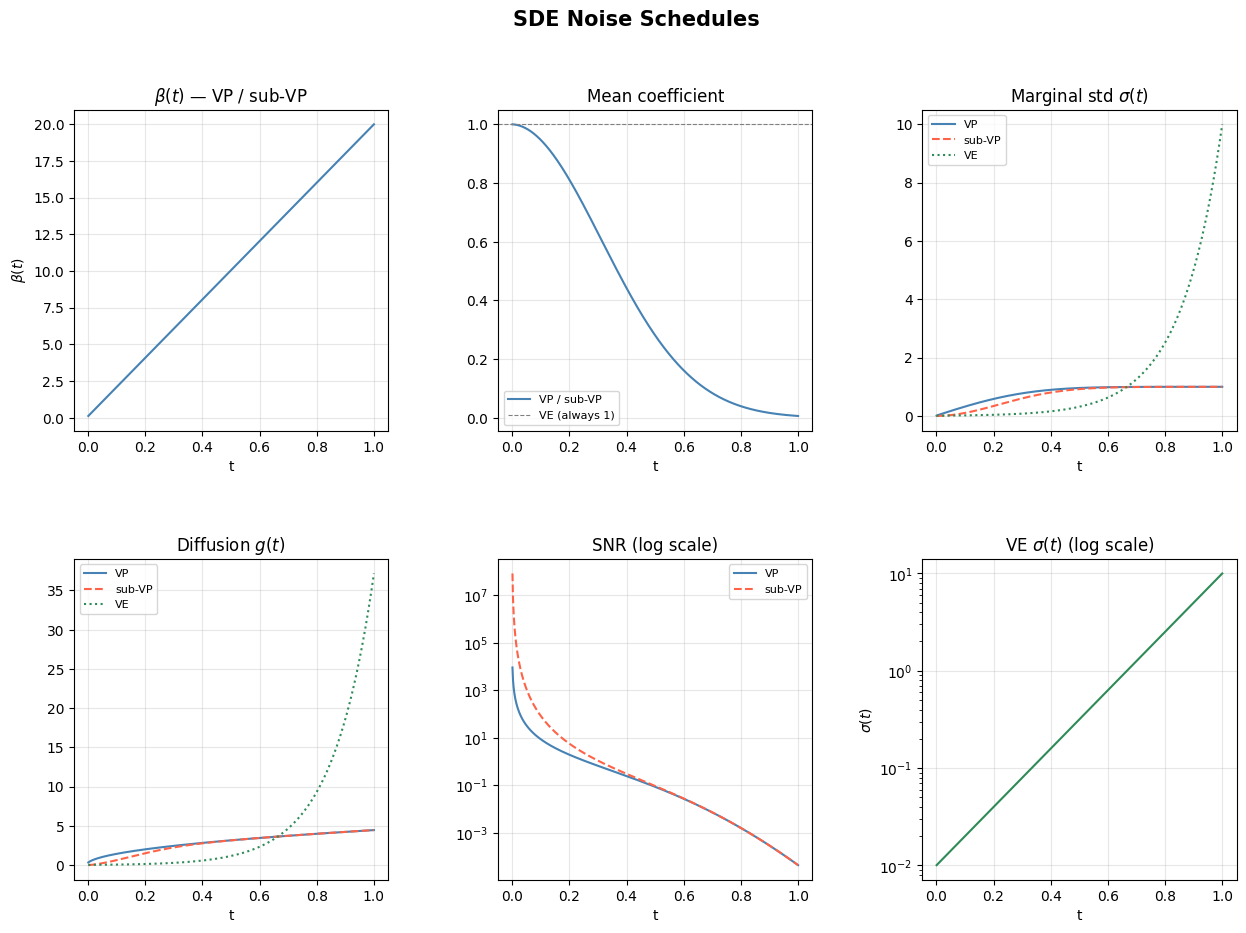

In [2]:
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import norm
from sde import VPSDE, subVPSDE, VESDE

vp  = VPSDE()
svp = subVPSDE()
ve  = VESDE(sigma_max=10.0)

t    = np.linspace(1e-3, 1.0, 1000)   # avoid t=0 (SNR blows up)
t_j  = jnp.array(t)
ones = jnp.ones_like(t_j)

# marginal stats — pass x=1 so mean output == mean_coeff
vp_mc,  vp_std  = vp.marginal_prob(ones, t_j)
svp_mc, svp_std = svp.marginal_prob(ones, t_j)
_,      ve_std  = ve.marginal_prob(ones, t_j)   # mean is always 1 for VE

# diffusion g(t)
_, vp_g  = vp.sde(ones, t_j)
_, svp_g = svp.sde(ones, t_j)
_, ve_g  = ve.sde(ones, t_j)

beta_t = np.array(vp_g) ** 2            # VP: g = sqrt(β) → β = g²

# ── Plot ─────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(15, 10))
fig.suptitle("SDE Noise Schedules", fontsize=15, fontweight="bold")
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)
ax  = [fig.add_subplot(gs[r, c]) for r in range(2) for c in range(3)]

ax[0].plot(t, beta_t, color="steelblue")
ax[0].set_title(r"$\beta(t)$ — VP / sub-VP")
ax[0].set_xlabel("t"); ax[0].set_ylabel(r"$\beta(t)$")

ax[1].plot(t, np.array(vp_mc), label="VP / sub-VP", color="steelblue")
ax[1].axhline(1, color="gray", ls="--", lw=0.8, label="VE (always 1)")
ax[1].set_title("Mean coefficient"); ax[1].set_xlabel("t"); ax[1].legend(fontsize=8)

ax[2].plot(t, np.array(vp_std),  label="VP",     color="steelblue")
ax[2].plot(t, np.array(svp_std), label="sub-VP", color="tomato",   ls="--")
ax[2].plot(t, np.array(ve_std),  label="VE",     color="seagreen", ls=":")
ax[2].set_title(r"Marginal std $\sigma(t)$"); ax[2].set_xlabel("t"); ax[2].legend(fontsize=8)

ax[3].plot(t, np.array(vp_g),  label="VP",     color="steelblue")
ax[3].plot(t, np.array(svp_g), label="sub-VP", color="tomato",   ls="--")
ax[3].plot(t, np.array(ve_g),  label="VE",     color="seagreen", ls=":")
ax[3].set_title(r"Diffusion $g(t)$"); ax[3].set_xlabel("t"); ax[3].legend(fontsize=8)

vp_snr  = np.array(vp_mc)**2  / np.array(vp_std)**2
svp_snr = np.array(svp_mc)**2 / np.array(svp_std)**2
ax[4].semilogy(t, vp_snr,  label="VP",     color="steelblue")
ax[4].semilogy(t, svp_snr, label="sub-VP", color="tomato",   ls="--")
ax[4].set_title("SNR (log scale)"); ax[4].set_xlabel("t"); ax[4].legend(fontsize=8)

ax[5].semilogy(t, np.array(ve_std), color="seagreen")
ax[5].set_title(r"VE $\sigma(t)$ (log scale)"); ax[5].set_xlabel("t"); ax[5].set_ylabel(r"$\sigma(t)$")

for a in ax: a.grid(True, alpha=0.3)
plt.savefig("noise_schedule.png", dpi=300, bbox_inches="tight")
plt.show()


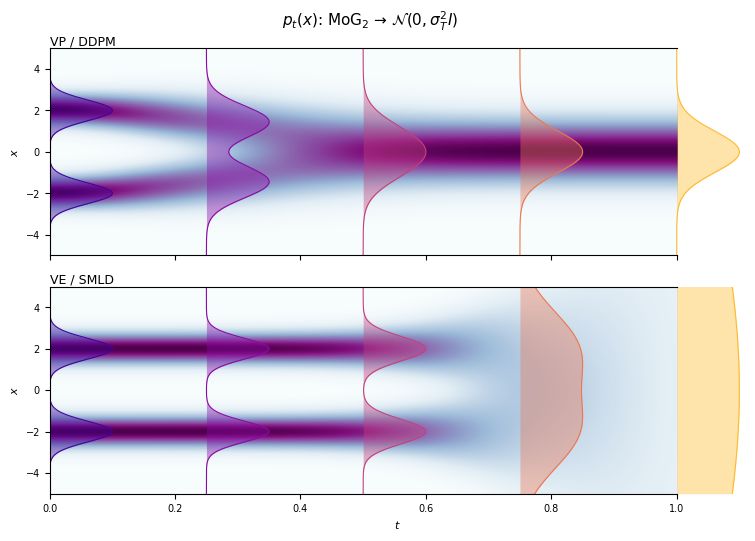

In [56]:

# ── VP/DDPM vs VE/SMLD: heatmap + discrete PDF overlays ──────────────────────
mu, s = 2.0, 0.5
T_steps = np.linspace(0, 1, 300)
t_j, dummy = jnp.array(T_steps), jnp.ones(len(T_steps))

def mog2(x, a, sig):
    v = np.sqrt(a**2 * s**2 + sig**2)
    return 0.5 * (norm.pdf(x[:, None], -a*mu, v) + norm.pdf(x[:, None], a*mu, v))

def heat(sde, xg):
    a, sig = sde.marginal_prob(dummy, t_j)
    return mog2(xg, np.array(a), np.array(sig))

def pdf_at(sde, xg, tv):
    a, sig = sde.marginal_prob(jnp.ones(1), jnp.array([max(tv, 1e-4)]))
    v = np.sqrt(float(a[0])**2 * s**2 + float(sig[0])**2)
    return 0.5 * (norm.pdf(xg, -float(a[0])*mu, v) + norm.pdf(xg, float(a[0])*mu, v))

xg = np.linspace(-5, 5, 300)
t_snaps = [0.0, 0.25, 0.5, 0.75, 1.0]
pal = [plt.cm.plasma(v) for v in np.linspace(0.1, 0.85, 5)]
w = 0.10

fig, axes = plt.subplots(2, 1, figsize=(8, 5.5), sharex=True,
                         gridspec_kw=dict(hspace=0.15, left=0.1, right=0.97, top=0.91, bottom=0.1))
fig.suptitle(r"$p_t(x)$: MoG$_2$ $\to$ $\mathcal{N}(0,\sigma_{T}^2I)$", fontsize=11)

for ax, (label, sde) in zip(axes, [("VP / DDPM", vp), ("VE / SMLD", ve)]):
    ht = heat(sde, xg)
    ax.imshow(ht, aspect="auto", origin="lower",
              extent=[0, 1, xg[0], xg[-1]], cmap="BuPu", vmin=0)
    ax.set_ylabel("$x$", fontsize=8)
    ax.set_title(label, fontsize=9, loc="left", pad=2)
    ax.tick_params(labelsize=7)

    for tv, col in zip(t_snaps, pal):
        p = pdf_at(sde, xg, tv);  pn = p / p.max() * w
        ax.fill_betweenx(xg, tv, tv + pn, color=col, alpha=0.4, lw=0)
        ax.plot(tv + pn, xg, color=col, lw=0.8)

    ax.set_xlim(0, 1 + w * 1.1)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_bounds(0, 1)
    ax.spines['bottom'].set_bounds(0, 1)

axes[-1].set_xlabel("$t$", fontsize=8)
plt.savefig("sde_comparison.png", dpi=300, bbox_inches="tight")
plt.show()


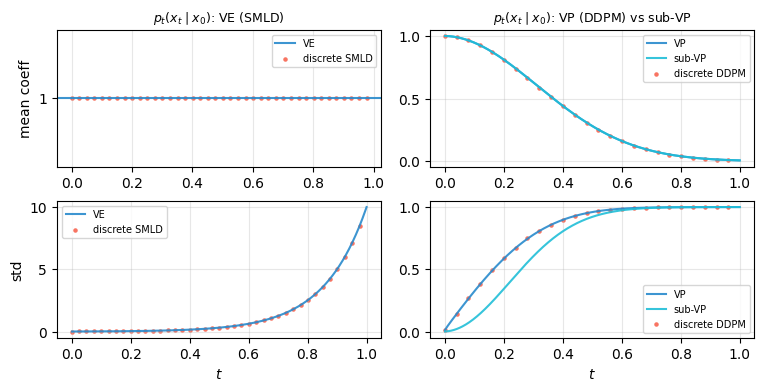

In [63]:

import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
from sde import VPSDE, subVPSDE, VESDE

vp  = VPSDE(N=500)
svp = subVPSDE()
ve  = VESDE(sigma_max=10.0, N=800)

t    = np.linspace(1e-3, 1.0, 800)
tj   = jnp.array(t)
ones = jnp.ones_like(tj)

# ── continuous marginals ─────────────────────────────────────────────────────
vp_mu,  vp_std  = vp.marginal_prob(ones, tj)
svp_mu, svp_std = svp.marginal_prob(ones, tj)
_,      ve_std  = ve.marginal_prob(ones, tj)

# ── discrete DDPM (VP) ───────────────────────────────────────────────────────
N = vp.N
t_disc   = np.linspace(0, 1, N)
ddpm_mu  = np.sqrt(np.array(vp.alphas_cumprod))
ddpm_std = np.sqrt(1 - np.array(vp.alphas_cumprod))

# ── discrete SMLD (VE) ───────────────────────────────────────────────────────
smld_t   = np.linspace(0, 1, ve.N)
smld_std = np.array(ve.discrete_sigmas)

stride = 20

# ── 2×2 figure: left=VE, right=VP/sub-VP ─────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(9, 4),
                         gridspec_kw=dict(hspace=0.25, wspace=0.15))
(ve_top, vp_top), (ve_bot, vp_bot) = axes[0], axes[1]
ve_color = "#288acc"
smld_color = "#F87462"
sub_vp_color = "#20BED7"
# VE — row 1: means
ve_top.axhline(1, color=ve_color, alpha=0.9,  lw=1.5, label="VE")
ve_top.scatter(smld_t[::stride], np.ones(ve.N // stride),
               s=5, color=smld_color, label="discrete SMLD")
ve_top.set_title(r"$p_t(x_t\mid x_0)$: VE (SMLD)", fontsize=9); ve_top.set_ylabel("mean coeff")
ve_top.set_yticks([1.0/1])  # hide x-axis ticks for top row
ve_top.legend(fontsize=7)

# VE — row 2: stds
ve_bot.plot(t, np.array(ve_std), color=ve_color, alpha=0.9, lw=1.5, label="VE")
ve_bot.scatter(smld_t[::stride], smld_std[::stride],
               s=5, color=smld_color, label="discrete SMLD")
ve_bot.set_ylabel("std"); ve_bot.set_xlabel("$t$"); ve_bot.legend(fontsize=7)

# VP/sub-VP — row 1: means
vp_top.plot(t, np.array(vp_mu),  color=ve_color, alpha=0.9, lw=1.5, label="VP")
vp_top.plot(t, np.array(svp_mu), color=sub_vp_color , alpha=0.9,    lw=1.5,  label="sub-VP")
vp_top.scatter(t_disc[::stride], ddpm_mu[::stride],
               s=5, color=smld_color, label="discrete DDPM")
vp_top.set_title(r"$p_t(x_t\mid x_0)$: VP (DDPM) vs sub-VP", fontsize=9); vp_top.legend(fontsize=7)

# VP/sub-VP — row 2: stds
vp_bot.plot(t, np.array(vp_std),  color=ve_color, alpha=0.9, lw=1.5, label="VP")
vp_bot.plot(t, np.array(svp_std), color=sub_vp_color , alpha=0.9,    lw=1.5, label="sub-VP")
vp_bot.scatter(t_disc[::stride], ddpm_std[::stride],
               s=5, color=smld_color, label="discrete DDPM")
vp_bot.set_xlabel("$t$"); vp_bot.legend(fontsize=7)

for a in axes.flat: a.grid(True, alpha=0.3)
plt.savefig("ve_vp_schedules.png", dpi=300, bbox_inches="tight")
plt.show()


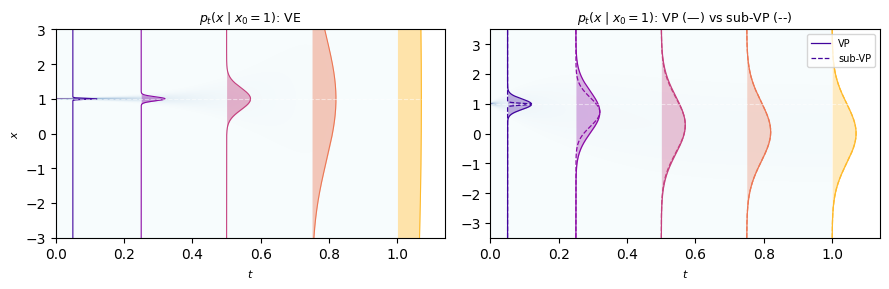

In [64]:

# ── Perturbation kernels p_t(x_t | x_0=1) ────────────────────────────────────
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
from scipy.stats import norm
from sde import VPSDE, subVPSDE, VESDE

vp  = VPSDE()
svp = subVPSDE()
ve  = VESDE(sigma_max=10.0)

x0   = 1.0
t    = np.linspace(1e-3, 1.0, 300)
tj   = jnp.array(t)
ones = jnp.ones_like(tj) * x0

vp_mu,  vp_std  = [np.array(a) for a in vp.marginal_prob(ones, tj)]
svp_mu, svp_std = [np.array(a) for a in svp.marginal_prob(ones, tj)]
ve_mu,  ve_std  = [np.array(a) for a in ve.marginal_prob(ones, tj)]

t_snaps = [0.05, 0.25, 0.5, 0.75, 1.0]
pal = [plt.cm.plasma(v) for v in np.linspace(0.1, 0.85, len(t_snaps))]
w = 0.07
xg_vp = np.linspace(-3.5, 3.5, 400)

fig, (ax_ve, ax_vp) = plt.subplots(1, 2, figsize=(9, 3))

# ── left: VE ─────────────────────────────────────────────────────────────────
xg_ve = np.linspace(-3, 3, 400)
dens = norm.pdf(xg_ve[:, None], ve_mu[None, :], ve_std[None, :])
ax_ve.imshow(dens, aspect="auto", origin="lower",
             extent=[0, 1, xg_ve[0], xg_ve[-1]], cmap="BuPu", vmin=0)
for tv, col in zip(t_snaps, pal):
    idx = np.argmin(np.abs(t - tv))
    p = norm.pdf(xg_ve, ve_mu[idx], ve_std[idx]); pn = p / p.max() * w
    ax_ve.fill_betweenx(xg_ve, tv, tv + pn, color=col, alpha=0.4, lw=0)
    ax_ve.plot(tv + pn, xg_ve, color=col, lw=0.8)
ax_ve.axhline(x0, color="white", lw=0.8, ls="--", alpha=0.5)
ax_ve.set_xlim(0, 1 + w * 2)
ax_ve.set_title(r"$p_t(x\mid x_0{=}1)$: VE", fontsize=9)
ax_ve.set_xlabel("$t$", fontsize=8); ax_ve.set_ylabel("$x$", fontsize=8)

# ── right: VP + sub-VP overlaid ──────────────────────────────────────────────
dens_vp = norm.pdf(xg_vp[:, None], vp_mu[None, :], vp_std[None, :])
ax_vp.imshow(dens_vp, aspect="auto", origin="lower",
             extent=[0, 1, xg_vp[0], xg_vp[-1]], cmap="BuPu", vmin=0)
for tv, col in zip(t_snaps, pal):
    idx = np.argmin(np.abs(t - tv))
    # VP — solid
    p = norm.pdf(xg_vp, vp_mu[idx], vp_std[idx]); pn = p / p.max() * w
    ax_vp.fill_betweenx(xg_vp, tv, tv + pn, color=col, alpha=0.3, lw=0)
    ax_vp.plot(tv + pn, xg_vp, color=col, lw=0.9, label="VP" if tv == t_snaps[0] else "")
    # sub-VP — dashed, same color
    p2 = norm.pdf(xg_vp, svp_mu[idx], svp_std[idx]); pn2 = p2 / p2.max() * w
    ax_vp.plot(tv + pn2, xg_vp, color=col, lw=0.9, ls="--", label="sub-VP" if tv == t_snaps[0] else "")
ax_vp.axhline(x0, color="white", lw=0.8, ls="--", alpha=0.5)
ax_vp.set_xlim(0, 1 + w * 2)
ax_vp.set_title(r"$p_t(x\mid x_0{=}1)$: VP (—) vs sub-VP (--)", fontsize=9)
ax_vp.set_xlabel("$t$", fontsize=8)
ax_vp.legend(fontsize=7, loc="upper right")

plt.tight_layout()
plt.savefig("perturbation_kernels.png", dpi=300, bbox_inches="tight")
plt.show()


In [48]:
ve_mu[idx], ve_std[idx]

(1.0, DeviceArray(0.13320813, dtype=float32))